In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from jaxtyping import Float
from transformer_lens import HookedTransformer, HookedTransformerConfig

In [ ]:

model_trained = HookedTransformer.from_pretrained("gpt2-small")
model_cfg = model_trained.cfg

# randomize the weights of model
model = HookedTransformer(HookedTransformerConfig.from_dict(model_cfg.to_dict()))

state_dict = model.state_dict()

for k, tensor in state_dict.items():
	if tensor.isnan().any():
		# set the tensor to random gaussian
		print(f"replacing {k} with random tensor")
		state_dict[k] = torch.randn_like(tensor)

model.load_state_dict(state_dict)

for k, tensor in model.state_dict().items():
	if tensor.isnan().any():
		# set the tensor to random gaussian
		print(f"{k} still has nans")



In [ ]:
logits, cache = model.run_with_cache("tial idea was to create something where humanity tried to evolve to a next level but had some kind of foe trying to stop them from doing so. I kind of had this image of human souls fly")

In [ ]:
fig, ax = plt.subplots(ncols=model_cfg.n_heads, nrows=model_cfg.n_layers, figsize=(50, 50))

for layer in range(model_cfg.n_layers):
	for head in range(model_cfg.n_heads):
		# ax[layer, head].matshow(cache[f"blocks.{layer}.attn.hook_attn_scores"][0, head].cpu().numpy())
		# with colorbar
		im = ax[layer, head].imshow(cache[f"blocks.{layer}.attn.hook_pattern"][0, head].cpu().numpy())
		fig.colorbar(im, ax=ax[layer, head])

In [1]:
from attention_motifs.array_info import array_summary
from jaxtyping import Float
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{xcolor}",
})



𝓡=[-1.39,2.08] μ=0.02 σ=0.30 x̃=0.00 ▁▇█▁▁ shape=(50,50) dtype=float64


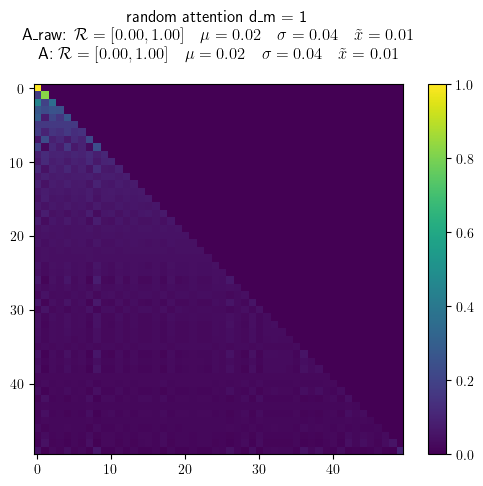

𝓡=[-17.79,15.69] μ=-0.00 σ=1.99 x̃=0.00 ▁▁█▁▁ shape=(50,50) dtype=float64


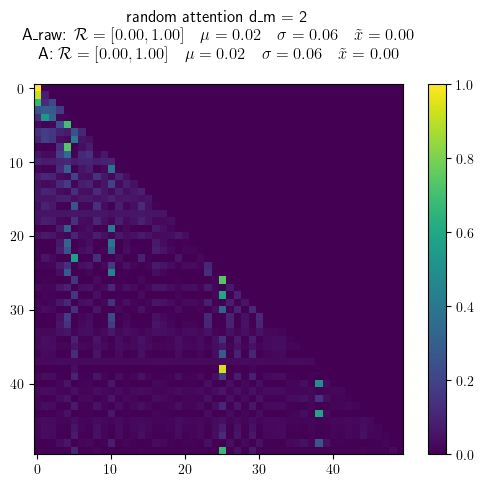

𝓡=[-51.68,50.67] μ=0.00 σ=6.89 x̃=0.01 ▁▁█▁▁ shape=(50,50) dtype=float64


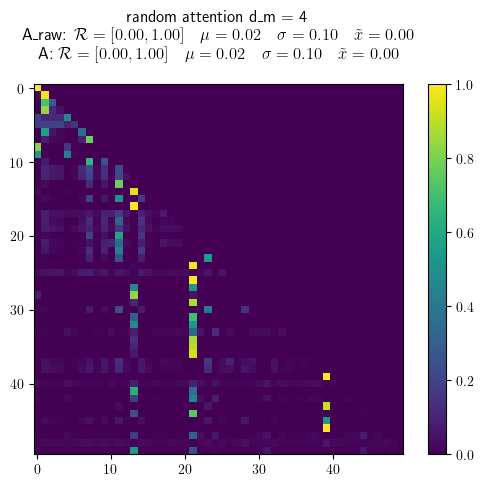

𝓡=[-32.67,32.68] μ=0.00 σ=6.34 x̃=0.00 ▁▁█▁▁ shape=(50,50) dtype=float64


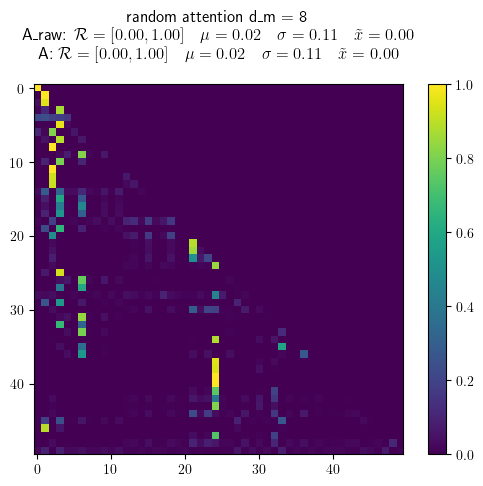

𝓡=[-167.35,170.45] μ=-0.55 σ=30.11 x̃=-0.53 ▁▁█▁▁ shape=(50,50) dtype=float64


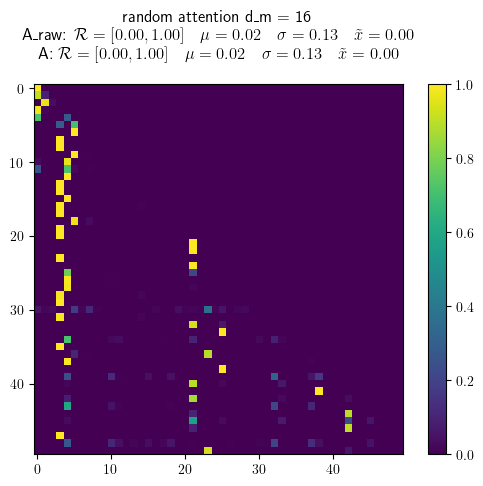

𝓡=[-224.93,235.59] μ=-0.80 σ=43.54 x̃=-1.04 ▁▂█▁▁ shape=(50,50) dtype=float64


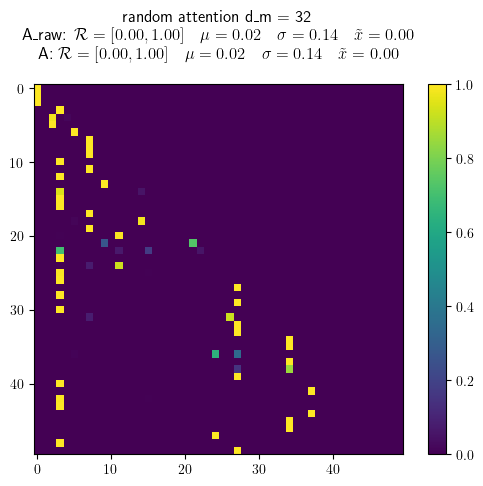

𝓡=[-452.63,353.82] μ=0.75 σ=78.95 x̃=0.24 ▁▁█▄▁ shape=(50,50) dtype=float64


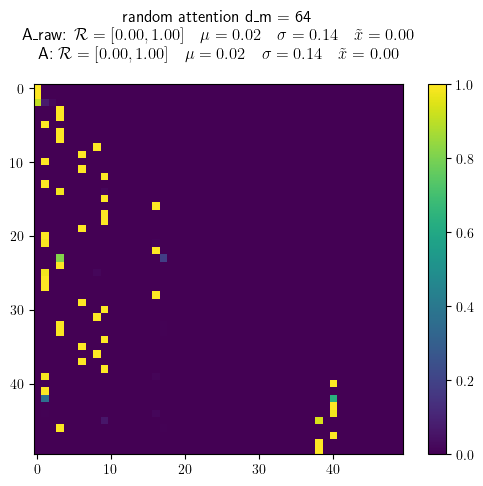

𝓡=[-769.88,976.70] μ=2.96 σ=181.66 x̃=1.66 ▁▄█▁▁ shape=(50,50) dtype=float64


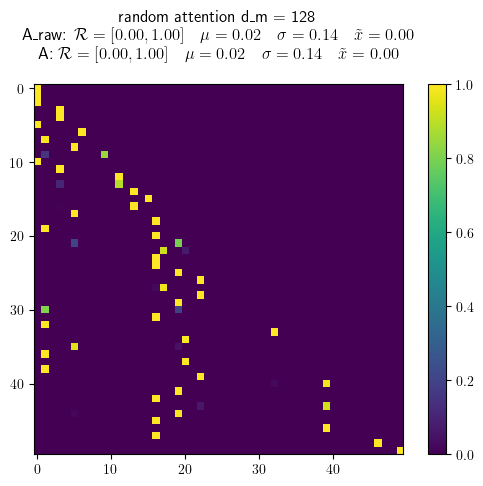

𝓡=[-1924.83,1429.43] μ=1.37 σ=306.13 x̃=1.63 ▁▁█▄▁ shape=(50,50) dtype=float64


/tmp/ipykernel_27779/3498405281.py:5: RuntimeWarning: overflow encountered in exp
  A = np.exp(A) / np.sum(np.exp(A), axis=1, keepdims=True)
/tmp/ipykernel_27779/3498405281.py:5: RuntimeWarning: invalid value encountered in divide
  A = np.exp(A) / np.sum(np.exp(A), axis=1, keepdims=True)


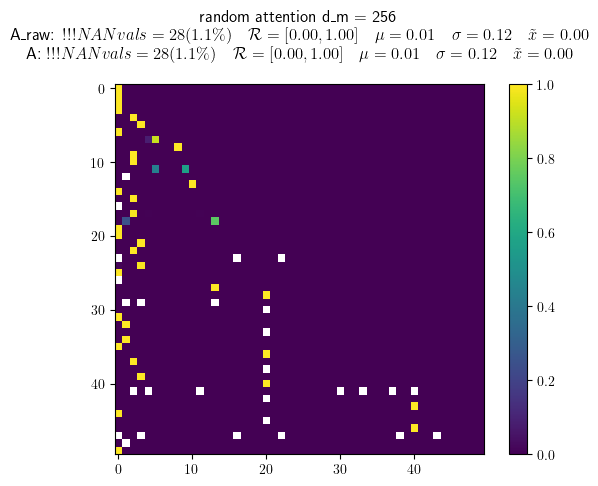

In [ ]:
def mask_and_softmax(A: Float[np.ndarray, "n_ctx n_ctx"]) -> Float[np.ndarray, "n_ctx n_ctx"]:
	n_ctx: int = A.shape[-1]
	A[np.triu_indices(n_ctx, 1)] = -np.inf
	# row wise softmax
	A = np.exp(A) / np.sum(np.exp(A), axis=1, keepdims=True)
	return A

def get_unif_attn(n_ctx: int) -> Float[np.ndarray, "n_ctx n_ctx"]:
	"""Get the random attention (row-uniform) matrix."""
	A = np.ones((n_ctx, n_ctx), dtype=float)
	return mask_and_softmax(A)

def get_rand_attn(
		n_ctx: int,
		d_model: int = 128,
		d_head: int = 16,
		pre_softmax: bool = False,
	) -> Float[np.ndarray, "n_ctx n_ctx"]:
	X = np.random.randn(n_ctx, d_model)
	W_q = np.random.randn(d_model, d_head)
	W_k = np.random.randn(d_model, d_head)
	A = X @ W_q @ W_k.T @ X.T
	# return A
	if pre_softmax:
		return A
	else:
		return mask_and_softmax(A)

# plt.imshow(get_unif_attn(50))
# plt.title("uniform attention")
# plt.colorbar()
# plt.show()

for d_m in [1, 2, 4, 8, 16, 32, 64, 128, 256]:
	A_raw = get_rand_attn(50, d_m, 2, pre_softmax=True)
	print(array_summary(A_raw, fmt="unicode", colored=True, sparkline=True))
	A = mask_and_softmax(A_raw)
	print(array_summary(A, fmt="unicode", colored=True, sparkline=True))
	plt.imshow(A)
	plt.title(		
		f"random attention {d_m = }\n"
		f"A_raw: ${array_summary(A, fmt='latex', colored=False, shape=False, dtype=False)}$\n"
		f"A: ${array_summary(A, fmt='latex', colored=False, shape=False, dtype=False)}$\n"
	)
	plt.colorbar()
	plt.show()